<a href="https://colab.research.google.com/github/khushbookhilnaney/surrogate-modeling-benchmark/blob/main/surrogate_model_benchmark.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install numpy pandas scikit-learn matplotlib

In [3]:
D=10
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

np.random.seed(42)

def ackley(X):
    """
    Ackley function (vectorized).
    X: shape (n_samples, d)
    Returns: shape (n_samples,)
    Domain commonly: [-5, 5]^d
    """
    X = np.asarray(X)
    d = X.shape[1]
    a = 20
    b = 0.2
    c = 2 * np.pi

    sum_sq = np.sum(X**2, axis=1)
    sum_cos = np.sum(np.cos(c * X), axis=1)

    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + a + np.e

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, WhiteKernel

np.random.seed(42)

def ackley(X):
    """
    Ackley function (vectorized).
    X: shape (n_samples, d)
    Returns: shape (n_samples,)
    Domain commonly: [-5, 5]^d
    """
    X = np.asarray(X)
    d = X.shape[1]
    a = 20
    b = 0.2
    c = 2 * np.pi

    sum_sq = np.sum(X**2, axis=1)
    sum_cos = np.sum(np.cos(c * X), axis=1)

    term1 = -a * np.exp(-b * np.sqrt(sum_sq / d))
    term2 = -np.exp(sum_cos / d)
    return term1 + term2 + a + np.e

In [8]:
def build_models():
    models = {}

    # 1) Polynomial regression (DOE/RSM style) with Ridge for stability
    models["Poly(RSM)+Ridge"] = Pipeline([
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=1.0))
    ])

    # 2) Random Forest (good general non-linear baseline)
    models["RandomForest"] = RandomForestRegressor(
        n_estimators=400,
        random_state=42
    )

    # 3) Support Vector Regression (kernel-based)
    models["SVR(RBF)"] = Pipeline([
        ("scaler", StandardScaler()),
        ("svr", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale"))
    ])

    # 4) Gaussian Process Regression (classic surrogate model, strong when data is small)
    kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=np.ones(D), length_scale_bounds=(1e-2, 1e2)) + WhiteKernel(noise_level=1e-3)
    models["GaussianProcess"] = Pipeline([
        ("scaler", StandardScaler()),
        ("gpr", GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42))
    ])

    return models

models = build_models()
list(models.keys())

['Poly(RSM)+Ridge', 'RandomForest', 'SVR(RBF)', 'GaussianProcess']

In [9]:
import numpy as np
from sklearn.model_selection import train_test_split

np.random.seed(42)

# Ackley function (simulates an expensive experiment)
def ackley(X):
    X = np.asarray(X)
    d = X.shape[1]

    a = 20
    b = 0.2
    c = 2*np.pi

    sum_sq = np.sum(X**2, axis=1)
    sum_cos = np.sum(np.cos(c*X), axis=1)

    term1 = -a*np.exp(-b*np.sqrt(sum_sq/d))
    term2 = -np.exp(sum_cos/d)

    return term1 + term2 + a + np.e


# Generate synthetic dataset
D = 10
N = 800

X = np.random.uniform(-5,5,(N,D))
y = ackley(X)

# Train test split
X_train_all, X_test, y_train_all, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Training size:", X_train_all.shape)
print("Test size:", X_test.shape)

Training size: (600, 10)
Test size: (200, 10)


In [10]:
def benchmark(models, X_train_all, y_train_all, X_test, y_test,
              train_sizes=(10, 20, 40, 80, 120, 200, 300, 450),
              n_repeats=5):
    results = []

    n_available = X_train_all.shape[0]
    train_sizes = [s for s in train_sizes if s <= n_available]

    for model_name, model in models.items():
        for n in train_sizes:
            mses = []
            for r in range(n_repeats):
                # sample n points from the available training pool
                idx = np.random.choice(n_available, size=n, replace=False)
                X_train = X_train_all[idx]
                y_train = y_train_all[idx]

                # fit + predict
                try:
                    model.fit(X_train, y_train)
                    preds = model.predict(X_test)
                    mse = mean_squared_error(y_test, preds)
                    mses.append(mse)
                except Exception as e:
                    # if a model fails for a given n, record NaN
                    mses.append(np.nan)

            results.append({
                "model": model_name,
                "train_size": n,
                "mse_mean": np.nanmean(mses),
                "mse_std": np.nanstd(mses)
            })

    return pd.DataFrame(results)

df_results = benchmark(models, X_train_all, y_train_all, X_test, y_test)
df_results.head()

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 4 of parameter k1__k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Conv

,model,train_size,mse_mean,mse_std
0,Poly(RSM)+Ridge,10,1.319161,0.728575
1,Poly(RSM)+Ridge,20,0.906966,0.076248
2,Poly(RSM)+Ridge,40,0.624620,0.054211
3,Poly(RSM)+Ridge,80,0.309528,0.054184
4,Poly(RSM)+Ridge,120,0.138617,0.029290


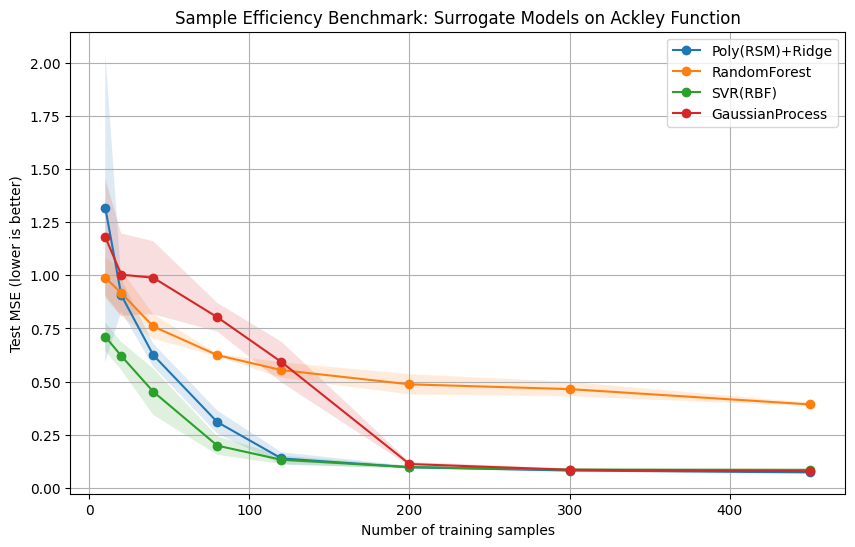

In [11]:
def plot_results(df):
    plt.figure(figsize=(10, 6))
    for model_name in df["model"].unique():
        sub = df[df["model"] == model_name].sort_values("train_size")
        plt.plot(sub["train_size"], sub["mse_mean"], marker="o", label=model_name)
        # error bars
        plt.fill_between(
            sub["train_size"],
            sub["mse_mean"] - sub["mse_std"],
            sub["mse_mean"] + sub["mse_std"],
            alpha=0.15
        )

    plt.xlabel("Number of training samples")
    plt.ylabel("Test MSE (lower is better)")
    plt.title("Sample Efficiency Benchmark: Surrogate Models on Ackley Function")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_results(df_results)